In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import seaborn as sns
import jax.random as random
import jax.numpy as jnp
import numpy as np
import optax
import os
from dataclasses import dataclass
from typing import List, Optional, Dict, Any, Tuple
import sys
import importlib.util
import re

from shearnet.core.dataset import generate_dataset, split_combined_images
from shearnet.config.config_handler import Config

from flax.training import checkpoints, train_state
from shearnet.utils.metrics import eval_model, eval_ngmix, remove_nan_preds_multi

from shearnet.utils.plot_helpers import (
    plot_residuals, 
    plot_true_vs_predicted, 
    animate_model_epochs
)


In [2]:
@dataclass
class ModelConfig:
    """Configuration for a ShearNet model to compare"""
    name: str  # Display name for plots
    model_dir_prefix: str  # Directory prefix to search for
    color: str  # Color for plots
    marker: str = 'o'  # Marker style for scatter plots
    
    def __post_init__(self):
        """Initialize configuration containers"""
        self.training_config = None
        self.test_config = None

In [3]:
# Define the models you want to compare
model_configs = [
    ModelConfig(
        name="fourth_validation_test",
        model_dir_prefix="fourth_validation_test",
        color="blue", 
        marker="s"
    ),
    ModelConfig(
        name="fourth_validation_d4forklike",
        model_dir_prefix="fourth_validation_d4forklike",
        color="green", 
        marker="s"
    ),
]

fourth_validation_test training stats:
  Final training loss: 0.047409
  Final validation loss: 0.071921
  Best validation loss: 0.066586 at epoch 22
  Total epochs: 42
fourth_validation_d4forklike training stats:
  Final training loss: 0.059371
  Final validation loss: 0.060732
  Best validation loss: 0.060725 at epoch 75
  Total epochs: 80


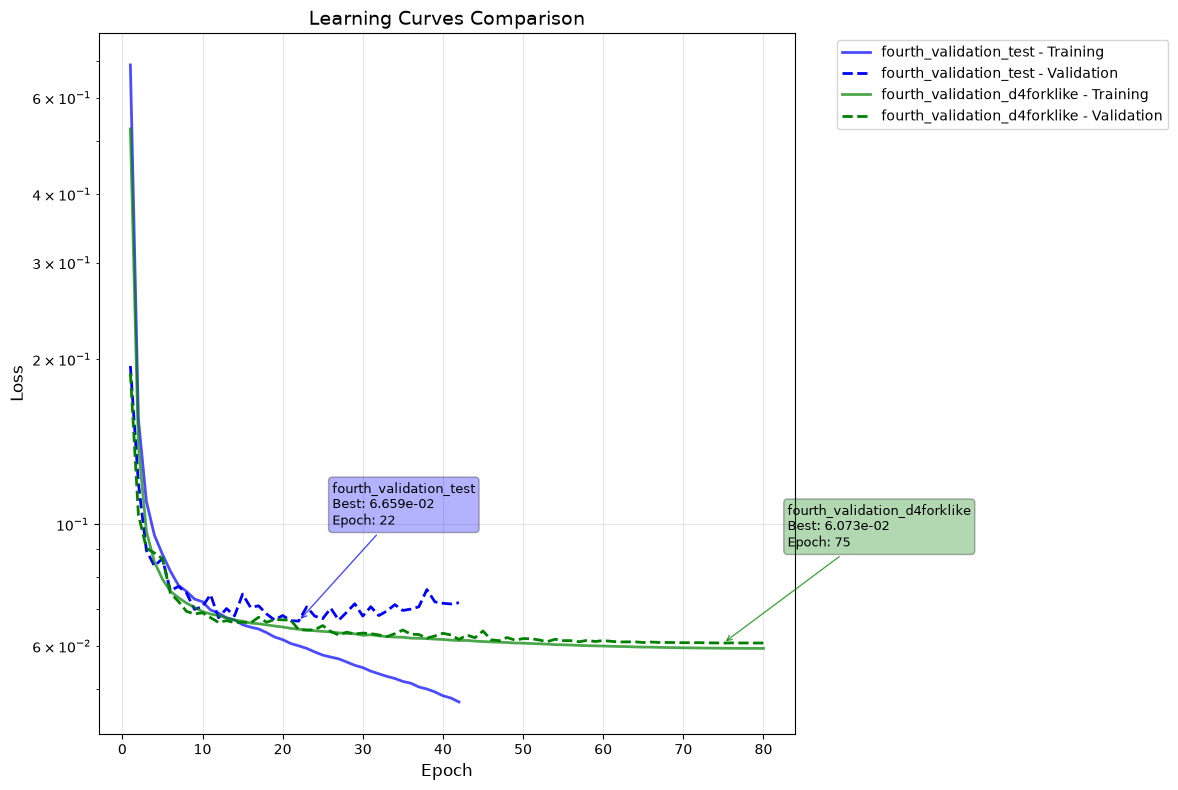

In [4]:
base_data_path = os.getenv('SHEARNET_DATA_PATH', os.path.abspath('.'))
    
plt.figure(figsize=(12, 8))

for config in model_configs:
    # Load loss data for this model
    loss_file = os.path.join(base_data_path, "plots", config.model_dir_prefix, f"{config.model_dir_prefix}_loss.npz")
    
    if os.path.exists(loss_file):
        loss = np.load(loss_file)
        train_loss = loss['train_loss']
        val_loss = loss['val_loss']
        
        epochs = np.arange(1, len(train_loss) + 1)
        
        # Plot with model-specific colors
        plt.plot(epochs, train_loss, color=config.color, linestyle='-', 
                label=f'{config.name} - Training', linewidth=2, alpha=0.7)
        plt.plot(epochs, val_loss, color=config.color, linestyle='--', 
                label=f'{config.name} - Validation', linewidth=2)
        
        # Add annotations for best validation loss
        best_val_epoch = np.argmin(val_loss) + 1
        best_val_loss = np.min(val_loss)
        plt.annotate(f'{config.name}\nBest: {best_val_loss:.3e}\nEpoch: {best_val_epoch}',
                    xy=(best_val_epoch, best_val_loss), 
                    xytext=(best_val_epoch + len(epochs)*0.1, best_val_loss * 1.5),
                    arrowprops=dict(arrowstyle='->', color=config.color, alpha=0.7),
                    fontsize=9,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor=config.color, alpha=0.3))
        
        # Log statistics
        print(f"{config.name} training stats:")
        print(f"  Final training loss: {train_loss[-1]:.6f}")
        print(f"  Final validation loss: {val_loss[-1]:.6f}") 
        print(f"  Best validation loss: {best_val_loss:.6f} at epoch {best_val_epoch}")
        print(f"  Total epochs: {len(train_loss)}")
    else:
        print(f"Warning: Loss file not found for {config.name}: {loss_file}")

plt.yscale("log")
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Learning Curves Comparison', fontsize=14)
plt.legend(fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

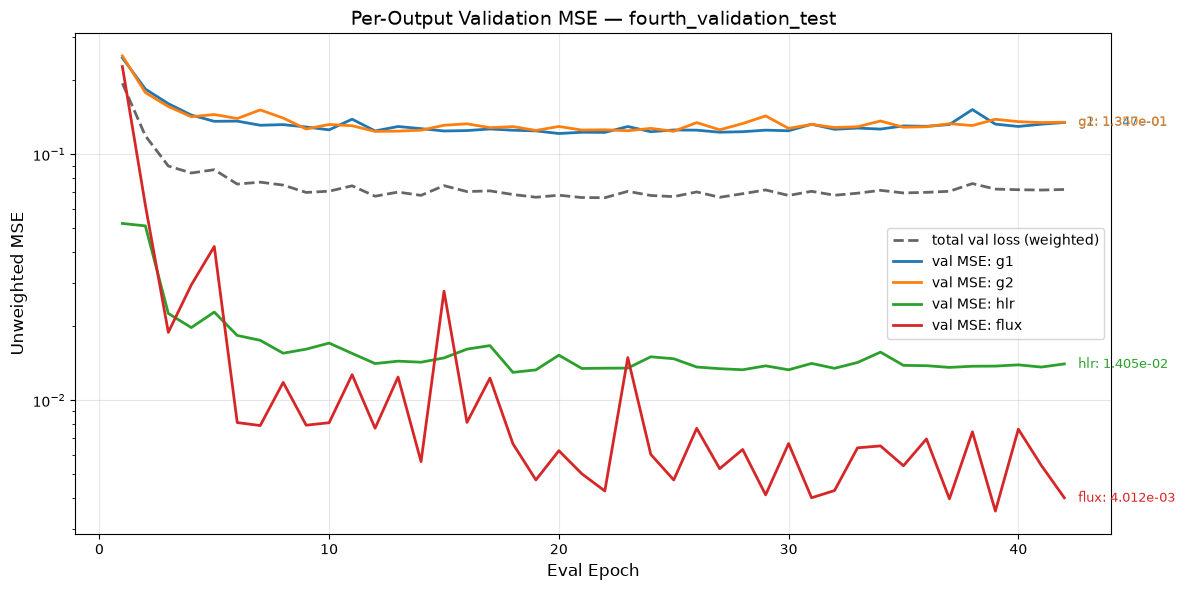


fourth_validation_test — per-key val MSE at best total-val epoch vs final epoch:
  key      best (ep 22)     final (ep 42)    ratio (final/best)  
  g1       1.2276e-01       1.3465e-01       1.10                
  g2       1.2581e-01       1.3497e-01       1.07                
  hlr      1.3497e-02       1.4048e-02       1.04                
  flux     4.2745e-03       4.0125e-03       0.94                


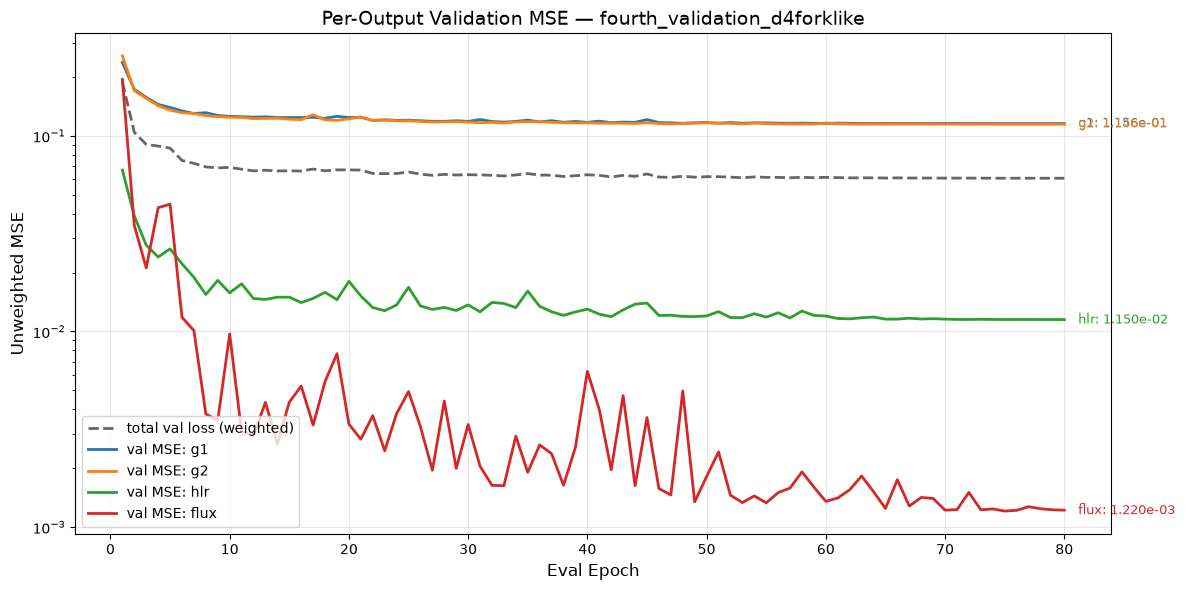


fourth_validation_d4forklike — per-key val MSE at best total-val epoch vs final epoch:
  key      best (ep 75)     final (ep 80)    ratio (final/best)  
  g1       1.1556e-01       1.1556e-01       1.00                
  g2       1.1463e-01       1.1465e-01       1.00                
  hlr      1.1506e-02       1.1504e-02       1.00                
  flux     1.2070e-03       1.2203e-03       1.01                


In [5]:
# Per-key validation loss breakdown
for config in model_configs:
    loss_file = os.path.join(base_data_path, "plots", config.model_dir_prefix, f"{config.model_dir_prefix}_loss.npz")
    
    if not os.path.exists(loss_file):
        print(f"Warning: Loss file not found for {config.name}: {loss_file}")
        continue

    loss = np.load(loss_file, allow_pickle=True)
    
    # Skip models that were trained before the per-key change
    if "val_loss_per_key" not in loss or "output_keys" not in loss:
        print(f"Skipping {config.name}: no per-key data (trained before diagnostic was added)")
        continue

    per_key = loss["val_loss_per_key"]    # shape (n_eval_epochs, n_out)
    keys = list(loss["output_keys"])      # e.g. ['g1', 'g2', 'hlr']
    val_loss = loss["val_loss"]

    n_eval_epochs = len(val_loss)
    epochs = np.arange(1, n_eval_epochs + 1)

    plt.figure(figsize=(12, 6))

    # Plot total val loss
    plt.plot(epochs, val_loss, color="black", linestyle="--", linewidth=2,
             label="total val loss (weighted)", alpha=0.6)

    # Plot each key
    colors_per_key = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
    for i, k in enumerate(keys):
        c = colors_per_key[i % len(colors_per_key)]
        plt.plot(epochs, per_key[:, i], color=c, linewidth=2, label=f"val MSE: {k}")

        # Annotate the final value
        plt.annotate(f"{k}: {per_key[-1, i]:.3e}",
                     xy=(epochs[-1], per_key[-1, i]),
                     xytext=(10, 0), textcoords="offset points",
                     fontsize=9, color=c, va="center")

    plt.yscale("log")
    plt.xlabel("Eval Epoch", fontsize=12)
    plt.ylabel("Unweighted MSE", fontsize=12)
    plt.title(f"Per-Output Validation MSE — {config.name}", fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.show()

    # Print a summary table
    print(f"\n{config.name} — per-key val MSE at best total-val epoch vs final epoch:")
    best_epoch_idx = int(np.argmin(val_loss))
    print(f"  {'key':<8} {'best (ep {})'.format(best_epoch_idx+1):<16} {'final (ep {})'.format(n_eval_epochs):<16} {'ratio (final/best)':<20}")
    for i, k in enumerate(keys):
        b = per_key[best_epoch_idx, i]
        f = per_key[-1, i]
        print(f"  {k:<8} {b:<16.4e} {f:<16.4e} {f/b:<20.2f}")

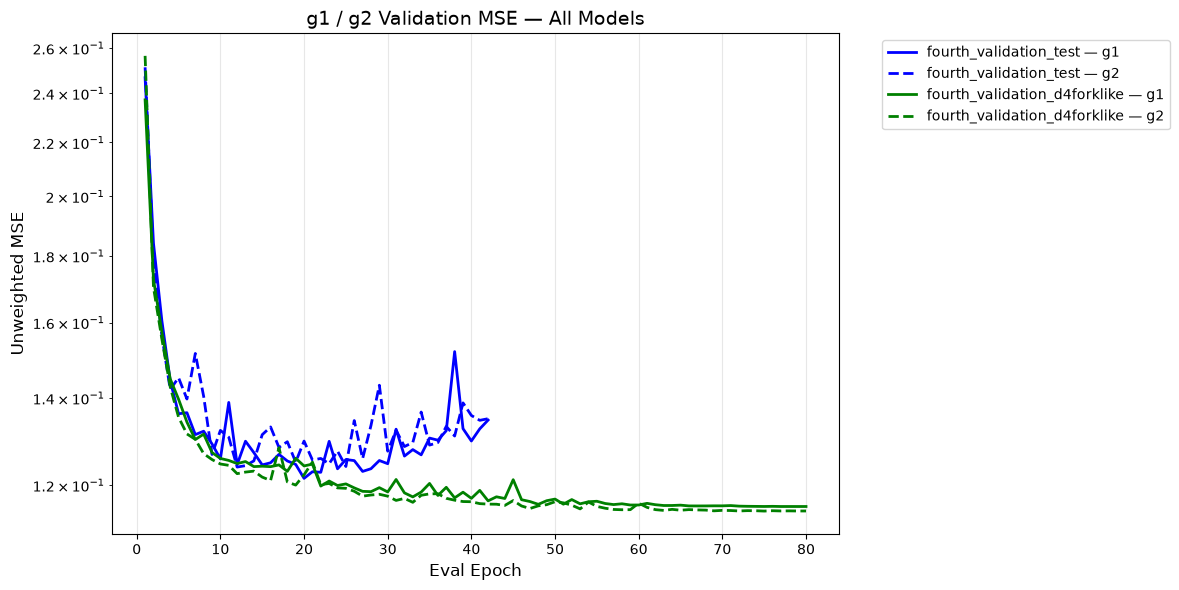

In [6]:
# g1 / g2 per-key validation loss — all models on one plot
plt.figure(figsize=(12, 6))

for config in model_configs:
    loss_file = os.path.join(base_data_path, "plots", config.model_dir_prefix, f"{config.model_dir_prefix}_loss.npz")

    if not os.path.exists(loss_file):
        print(f"Warning: Loss file not found for {config.name}: {loss_file}")
        continue

    loss = np.load(loss_file, allow_pickle=True)

    if "val_loss_per_key" not in loss or "output_keys" not in loss:
        print(f"Skipping {config.name}: no per-key data")
        continue

    per_key = loss["val_loss_per_key"]   # shape (n_eval_epochs, n_out)
    keys = list(loss["output_keys"])

    n_eval_epochs = per_key.shape[0]
    epochs = np.arange(1, n_eval_epochs + 1)

    for k, ls in [("g1", "-"), ("g2", "--")]:
        if k not in keys:
            continue
        idx = keys.index(k)
        plt.plot(epochs, per_key[:, idx], color=config.color, linestyle=ls,
                 linewidth=2, label=f"{config.name} — {k}")

plt.yscale("log")
plt.xlabel("Eval Epoch", fontsize=12)
plt.ylabel("Unweighted MSE", fontsize=12)
plt.title("g1 / g2 Validation MSE — All Models", fontsize=14)
plt.legend(fontsize=10, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()